In [1]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("../..") / ".env")

True

In [2]:
log = kairo.read_log("../../data/control-flow.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    event_id = "event:id",
    start_timestamp = "start_timestamp",
    resource = "org:resource",
    event_duration = "event:duration_min")
log.head()

,case:concept:name,case:region,org:resource,start_timestamp,event_duration,time:timestamp,concept:name,case:amount,event_id
0,case_000001,region_1,res_07,2020-01-01 00:00:00+00:00,35.405165,2020-01-01 00:35:24.309885+00:00,a,773.79,evt_00000001
1,case_000002,region_1,res_07,2020-01-01 00:06:38.973760+00:00,38.376058,2020-01-01 00:45:01.537250+00:00,a,888.66,evt_00000002
2,case_000002,region_1,res_05,2020-01-01 01:07:36.657076+00:00,18.844446,2020-01-01 01:26:27.323811+00:00,b,888.66,evt_00000003
3,case_000002,region_1,res_06,2020-01-01 01:26:33.323811+00:00,16.029880,2020-01-01 01:42:35.116597+00:00,c,888.66,evt_00000004
4,case_000002,region_1,res_04,2020-01-01 01:52:21.614661+00:00,33.038388,2020-01-01 02:25:23.917944+00:00,f,888.66,evt_00000005


In [3]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 300301,
 'events': 1767057,
 'activities': 16,
 'resources': 7,
 'start': Timestamp('2020-01-01 00:35:24.309885+0000', tz='UTC'),
 'end': Timestamp('2020-12-31 04:41:17.626539+0000', tz='UTC'),
 'span_minutes': 525845.8886109,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 0.15336215427729513,
 'tpt_days_median': 0.14329904908564814,
 'tpt_days_max': 2.696217871030093,
 'length_min': 1,
 'length_mean': 5.884286099613388,
 'length_median': 6.0,
 'length_max': 85,
 'activity_counts': concept:name
 a    390230
 b    195362
 g    116374
 o    105618
 p    105618
 k    104797
 l    104797
 m    104612
 n    104612
 f    103175
 d     71394
 c     71033
 e     58148
 i     52488
 j     52309
 h     26490
 Name: count, dtype: int64,
 'resource_counts': org:resource
 res_07    588709
 res_05    332831
 res_02    274796
 res_04    227690
 res_06    138464
 res_03    132881
 res_01     71686
 Name: count, dtype: int64}

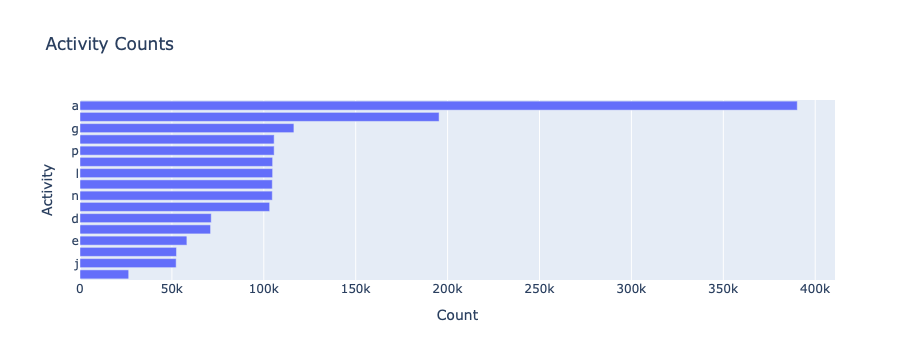

In [4]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [5]:
# one row per calendar window, resources=None keeps all resources
features = kairo.compute_features_resource(log, window="4h", resources=None)
features

,time:timestamp,res_events:res_01,res_events:res_02,res_events:res_03,res_events:res_04,res_events:res_05,res_events:res_06,res_events:res_07,res_cases:res_01,res_cases:res_02,...,handover_shares:res_06 -> res_03,handover_shares:res_06 -> res_04,handover_shares:res_06 -> res_05,handover_shares:res_06 -> res_07,handover_shares:res_07 -> res_01,handover_shares:res_07 -> res_02,handover_shares:res_07 -> res_03,handover_shares:res_07 -> res_04,handover_shares:res_07 -> res_05,handover_shares:res_07 -> res_06
0,2020-01-01 00:00:00+00:00,5.0,14.0,17.0,14.0,41.0,15.0,93.0,5.0,12.0,...,0.500000,0.125000,0.125000,0.125000,0.025641,0.000000,0.153846,0.051282,0.717949,0.051282
1,2020-01-01 04:00:00+00:00,21.0,45.0,70.0,59.0,86.0,35.0,203.0,20.0,40.0,...,0.750000,0.000000,0.083333,0.083333,0.057143,0.028571,0.276190,0.038095,0.580952,0.019048
2,2020-01-01 08:00:00+00:00,23.0,67.0,97.0,97.0,97.0,57.0,230.0,23.0,61.0,...,0.672414,0.034483,0.120690,0.051724,0.075630,0.000000,0.302521,0.042017,0.529412,0.050420
3,2020-01-01 12:00:00+00:00,23.0,72.0,114.0,101.0,110.0,60.0,257.0,20.0,65.0,...,0.800000,0.090909,0.000000,0.036364,0.033333,0.073333,0.300000,0.046667,0.500000,0.046667
4,2020-01-01 16:00:00+00:00,27.0,74.0,112.0,124.0,116.0,84.0,296.0,25.0,67.0,...,0.587302,0.079365,0.142857,0.079365,0.025641,0.038462,0.307692,0.057692,0.544872,0.025641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2020-12-30 12:00:00+00:00,53.0,151.0,23.0,102.0,161.0,60.0,244.0,46.0,123.0,...,0.018868,0.169811,0.377358,0.283019,0.052632,0.105263,0.030075,0.112782,0.563910,0.135338
2188,2020-12-30 16:00:00+00:00,33.0,139.0,26.0,77.0,153.0,47.0,227.0,32.0,111.0,...,0.021739,0.086957,0.586957,0.195652,0.065041,0.121951,0.016260,0.065041,0.569106,0.162602
2189,2020-12-30 20:00:00+00:00,50.0,142.0,31.0,96.0,145.0,55.0,259.0,45.0,119.0,...,0.088889,0.022222,0.488889,0.244444,0.030769,0.100000,0.061538,0.092308,0.492308,0.223077
2190,2020-12-31 00:00:00+00:00,18.0,123.0,9.0,79.0,73.0,36.0,156.0,18.0,95.0,...,0.051282,0.205128,0.358974,0.230769,0.029851,0.164179,0.044776,0.104478,0.462687,0.194030


In [6]:
std_features = kairo.standardize(features, method="minmax")
std_features

,time:timestamp,res_events:res_01,res_events:res_02,res_events:res_03,res_events:res_04,res_events:res_05,res_events:res_06,res_events:res_07,res_cases:res_01,res_cases:res_02,...,handover_shares:res_06 -> res_03,handover_shares:res_06 -> res_04,handover_shares:res_06 -> res_05,handover_shares:res_06 -> res_07,handover_shares:res_07 -> res_01,handover_shares:res_07 -> res_02,handover_shares:res_07 -> res_03,handover_shares:res_07 -> res_04,handover_shares:res_07 -> res_05,handover_shares:res_07 -> res_06
0,2020-01-01 00:00:00+00:00,0.068966,0.063158,0.098837,0.081395,0.195238,0.129310,0.237705,0.076923,0.066667,...,0.600000,0.487500,0.164286,0.125000,0.163818,0.000000,0.403596,0.329285,1.000000,0.148718
1,2020-01-01 04:00:00+00:00,0.344828,0.226316,0.406977,0.343023,0.409524,0.301724,0.538251,0.365385,0.253333,...,0.900000,0.000000,0.109524,0.083333,0.365079,0.155556,0.724552,0.244612,0.809184,0.055238
2,2020-01-01 08:00:00+00:00,0.379310,0.342105,0.563953,0.563953,0.461905,0.491379,0.612022,0.423077,0.393333,...,0.806897,0.134483,0.158621,0.051724,0.483193,0.000000,0.793627,0.269792,0.737395,0.146218
3,2020-01-01 12:00:00+00:00,0.379310,0.368421,0.662791,0.587209,0.523810,0.517241,0.685792,0.365385,0.420000,...,0.960000,0.354545,0.000000,0.036364,0.212963,0.399259,0.787013,0.299649,0.696429,0.135333
4,2020-01-01 16:00:00+00:00,0.448276,0.378947,0.651163,0.720930,0.552381,0.724138,0.792350,0.461538,0.433333,...,0.704762,0.309524,0.187755,0.079365,0.163818,0.209402,0.807193,0.370445,0.758929,0.074359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2020-12-30 12:00:00+00:00,0.896552,0.784211,0.133721,0.593023,0.766667,0.517241,0.650273,0.865385,0.806667,...,0.022642,0.662264,0.495957,0.283019,0.336257,0.573099,0.078899,0.724179,0.785446,0.392481
2188,2020-12-30 16:00:00+00:00,0.551724,0.721053,0.151163,0.447674,0.728571,0.405172,0.603825,0.596154,0.726667,...,0.026087,0.339130,0.771429,0.195652,0.415537,0.663957,0.042657,0.417629,0.792683,0.471545
2189,2020-12-30 20:00:00+00:00,0.844828,0.736842,0.180233,0.558140,0.690476,0.474138,0.691257,0.846154,0.780000,...,0.106667,0.086667,0.642540,0.244444,0.196581,0.544444,0.161439,0.592713,0.685714,0.646923
2190,2020-12-31 00:00:00+00:00,0.293103,0.636842,0.052326,0.459302,0.347619,0.310345,0.409836,0.326923,0.620000,...,0.061538,0.800000,0.471795,0.230769,0.190713,0.893864,0.117465,0.670856,0.644456,0.562687


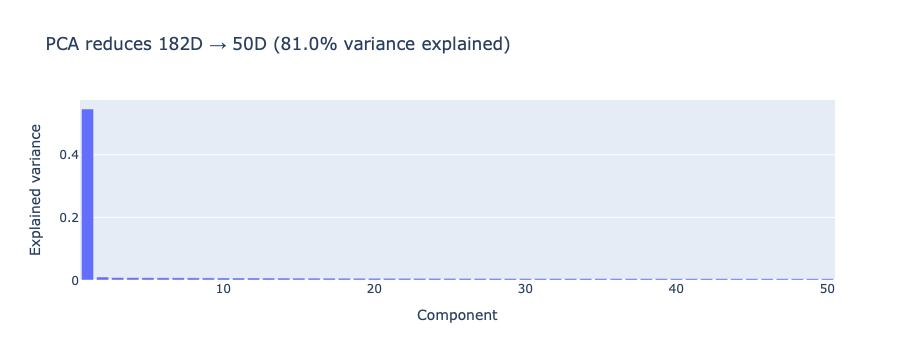

In [7]:
pca = kairo.compute_pca(std_features, num_components=50)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [ ]:
reconstruction_errors = kairo.compute_pca_reconstruction_errors(std_features, pca)
reconstruction_plot = kairo.plot_pca_reconstruction_errors(reconstruction_errors)
reconstruction_plot.show()

In [10]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=20)
compressed_features

,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,...,pc_11,pc_12,pc_13,pc_14,pc_15,pc_16,pc_17,pc_18,pc_19,pc_20
0,2020-01-01 00:00:00+00:00,-2.368723,-0.639647,-0.526775,-0.299577,-0.463488,0.451274,0.442714,0.280137,-0.365126,...,0.173610,-1.008603,0.173045,-0.366595,0.433611,-0.436227,-0.609340,0.040002,0.206697,-0.129407
1,2020-01-01 04:00:00+00:00,-2.564494,0.077792,-0.022349,-0.548817,-0.074386,0.007223,0.234754,0.050713,-0.251028,...,0.145425,-0.195327,-0.233978,-0.449904,0.395394,-0.303287,0.078962,-0.039698,0.100862,-0.270065
2,2020-01-01 08:00:00+00:00,-2.662885,0.048158,0.007940,-0.159142,-0.133786,-0.103606,0.363796,-0.113257,-0.299873,...,0.134092,-0.368072,-0.119855,-0.085211,0.214324,-0.142944,-0.061782,-0.245367,0.132347,-0.028255
3,2020-01-01 12:00:00+00:00,-2.707232,-0.067090,-0.068063,-0.273857,-0.191132,-0.186316,0.129898,0.042602,0.079815,...,0.231034,-0.232582,-0.036692,0.163570,0.155662,0.200424,0.095322,0.145851,-0.126577,0.005500
4,2020-01-01 16:00:00+00:00,-2.644132,0.051085,-0.064851,0.213320,0.052743,-0.010389,0.239017,-0.010705,-0.051973,...,-0.032054,-0.115187,0.134106,0.141463,0.137728,0.102886,-0.277816,0.259933,-0.008804,0.040831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2020-12-30 12:00:00+00:00,1.272354,0.797350,0.019468,0.012349,-0.117917,0.100655,-0.231755,-0.228024,-0.100386,...,-0.115231,0.198732,-0.392324,0.175458,0.184589,-0.103837,0.010162,-0.010633,0.173375,0.370535
2188,2020-12-30 16:00:00+00:00,1.257658,-0.179917,0.396022,-0.431937,-0.309564,0.130353,-0.141062,0.374457,-0.354807,...,0.099999,0.034082,-0.270087,-0.103716,0.106131,0.158892,-0.034769,0.000633,0.683887,0.095132
2189,2020-12-30 20:00:00+00:00,1.229919,0.487248,0.105947,-0.137662,0.151555,-0.581333,-0.226544,-0.033970,0.501878,...,0.388381,-0.050109,-0.157759,-0.099688,-0.095786,-0.073366,0.073318,0.273682,-0.056910,-0.074839
2190,2020-12-31 00:00:00+00:00,1.148876,-0.545653,-0.606054,-0.287058,-0.106656,-0.137950,-0.174116,0.248885,0.009786,...,0.068600,0.001350,-0.305301,-0.000790,1.002423,0.275215,-0.363889,0.136494,0.023281,0.136416


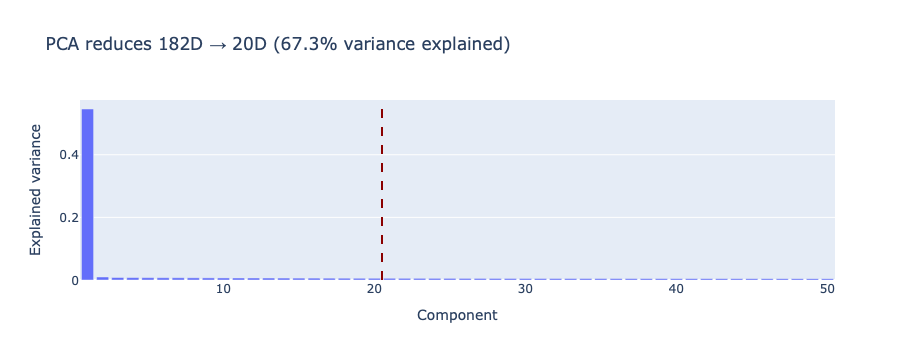

In [11]:
pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=20)
pca_plot_cut.show()

In [ ]:
reconstruction_plot_cut = kairo.plot_pca_reconstruction_errors(reconstruction_errors, cut_component=20)
reconstruction_plot_cut.show()

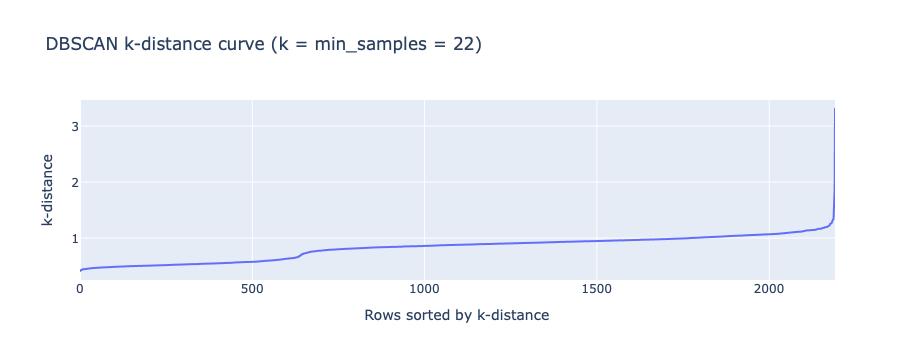

In [14]:
# try min_samples around D + 1, D being the number of PCA components, and eps at the knee
k_distances_plot = kairo.plot_dbscan_k_distance(compressed_features, min_samples=22, distance="euclidean")
k_distances_plot.show()

In [15]:
dbscan = kairo.compute_dbscan(compressed_features, min_samples=22, eps=1.3, distance="euclidean")
clusters = kairo.get_dbscan_clusters(compressed_features, dbscan)
clusters

,cluster
0,-1
1,0
2,0
3,0
4,0
...,...
2187,1
2188,1
2189,1
2190,1


In [16]:
clustering_scores = [
    {"type": "DBCV", "value": kairo.compute_dbcv(compressed_features, clusters, distance=dbscan.metric)},
    {"type": "Silhouette", "value": kairo.compute_silhouette(compressed_features, clusters, distance=dbscan.metric)},
    {"type": "Calinski-Harabasz", "value": kairo.compute_calinski_harabasz(compressed_features, clusters)},
]
clustering_scores

[{'type': 'DBCV', 'value': 0.7175837660935739},
 {'type': 'Silhouette', 'value': 0.7120766447372809},
 {'type': 'Calinski-Harabasz', 'value': 9449.256102821013}]

In [17]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)
features_and_clusters

,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,...,pc_12,pc_13,pc_14,pc_15,pc_16,pc_17,pc_18,pc_19,pc_20,cluster
0,2020-01-01 00:00:00+00:00,-2.368723,-0.639647,-0.526775,-0.299577,-0.463488,0.451274,0.442714,0.280137,-0.365126,...,-1.008603,0.173045,-0.366595,0.433611,-0.436227,-0.609340,0.040002,0.206697,-0.129407,-1
1,2020-01-01 04:00:00+00:00,-2.564494,0.077792,-0.022349,-0.548817,-0.074386,0.007223,0.234754,0.050713,-0.251028,...,-0.195327,-0.233978,-0.449904,0.395394,-0.303287,0.078962,-0.039698,0.100862,-0.270065,0
2,2020-01-01 08:00:00+00:00,-2.662885,0.048158,0.007940,-0.159142,-0.133786,-0.103606,0.363796,-0.113257,-0.299873,...,-0.368072,-0.119855,-0.085211,0.214324,-0.142944,-0.061782,-0.245367,0.132347,-0.028255,0
3,2020-01-01 12:00:00+00:00,-2.707232,-0.067090,-0.068063,-0.273857,-0.191132,-0.186316,0.129898,0.042602,0.079815,...,-0.232582,-0.036692,0.163570,0.155662,0.200424,0.095322,0.145851,-0.126577,0.005500,0
4,2020-01-01 16:00:00+00:00,-2.644132,0.051085,-0.064851,0.213320,0.052743,-0.010389,0.239017,-0.010705,-0.051973,...,-0.115187,0.134106,0.141463,0.137728,0.102886,-0.277816,0.259933,-0.008804,0.040831,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2020-12-30 12:00:00+00:00,1.272354,0.797350,0.019468,0.012349,-0.117917,0.100655,-0.231755,-0.228024,-0.100386,...,0.198732,-0.392324,0.175458,0.184589,-0.103837,0.010162,-0.010633,0.173375,0.370535,1
2188,2020-12-30 16:00:00+00:00,1.257658,-0.179917,0.396022,-0.431937,-0.309564,0.130353,-0.141062,0.374457,-0.354807,...,0.034082,-0.270087,-0.103716,0.106131,0.158892,-0.034769,0.000633,0.683887,0.095132,1
2189,2020-12-30 20:00:00+00:00,1.229919,0.487248,0.105947,-0.137662,0.151555,-0.581333,-0.226544,-0.033970,0.501878,...,-0.050109,-0.157759,-0.099688,-0.095786,-0.073366,0.073318,0.273682,-0.056910,-0.074839,1
2190,2020-12-31 00:00:00+00:00,1.148876,-0.545653,-0.606054,-0.287058,-0.106656,-0.137950,-0.174116,0.248885,0.009786,...,0.001350,-0.305301,-0.000790,1.002423,0.275215,-0.363889,0.136494,0.023281,0.136416,1


In [18]:
state_distances = kairo.get_dbscan_state_distances(dbscan)
state_distances

,0,1
0,0.000000,3.950805
1,3.950805,0.000000


In [19]:
state_freqs = kairo.get_dbscan_state_frequencies(features_and_clusters)
state_freqs

state
noise       3
0         656
1        1533
Name: windows, dtype: int64

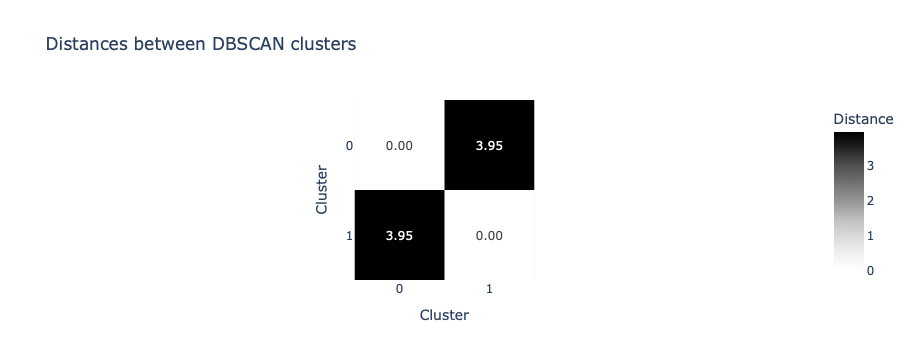

In [20]:
distances_plot = kairo.plot_dbscan_distances(state_distances)
distances_plot.show()

In [21]:
color_mapping = kairo.compute_dbscan_color_mapping(dbscan)

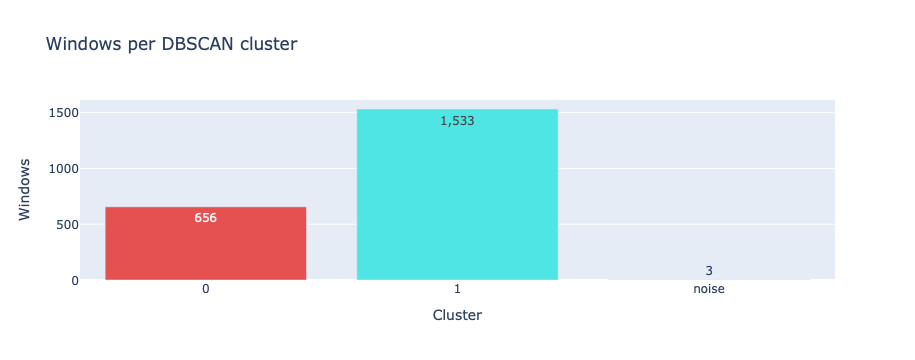

In [22]:
freqs_plot = kairo.plot_dbscan_frequencies(state_freqs, color_mapping)
freqs_plot.show()

In [23]:
log_trajectory = kairo.get_dbscan_log_trajectory(features_and_clusters,
                                 #start_date="2020-01-01",
                                 #end_date="2020-04-30"
                                 )
log_trajectory

,state,start,end,duration,windows
0,noise,2020-01-01 00:00:00+00:00,2020-01-01 04:00:00+00:00,0 days 04:00:00,1
1,0,2020-01-01 04:00:00+00:00,2020-04-19 12:00:00+00:00,109 days 08:00:00,656
2,noise,2020-04-19 12:00:00+00:00,2020-04-19 16:00:00+00:00,0 days 04:00:00,1
3,1,2020-04-19 16:00:00+00:00,2020-12-31 04:00:00+00:00,255 days 12:00:00,1533
4,noise,2020-12-31 04:00:00+00:00,2020-12-31 08:00:00+00:00,0 days 04:00:00,1


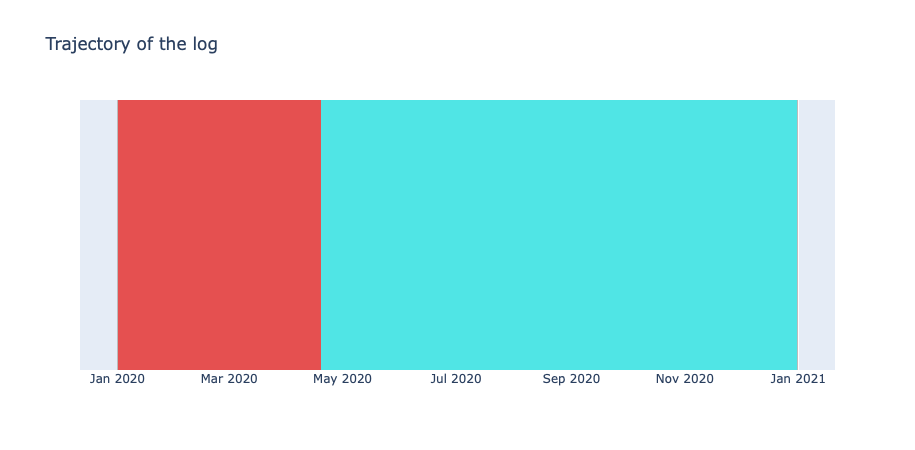

In [24]:
log_trajectory_plot = kairo.plot_dbscan_log_trajectory(log_trajectory, color_mapping)
log_trajectory_plot

In [25]:
# the states of the daily windows counted per 30 days
freq_distributions = kairo.compute_state_distributions(features_and_clusters, window="30D")
freq_distributions

state,noise,0,1
window,,,
2019-12-10 00:00:00+00:00,0.020833,0.979167,0.000000
2020-01-09 00:00:00+00:00,0.000000,1.000000,0.000000
2020-02-08 00:00:00+00:00,0.000000,1.000000,0.000000
2020-03-09 00:00:00+00:00,0.000000,1.000000,0.000000
2020-04-08 00:00:00+00:00,0.005556,0.383333,0.611111
2020-05-08 00:00:00+00:00,0.000000,0.000000,1.000000
2020-06-07 00:00:00+00:00,0.000000,0.000000,1.000000
2020-07-07 00:00:00+00:00,0.000000,0.000000,1.000000
2020-08-06 00:00:00+00:00,0.000000,0.000000,1.000000


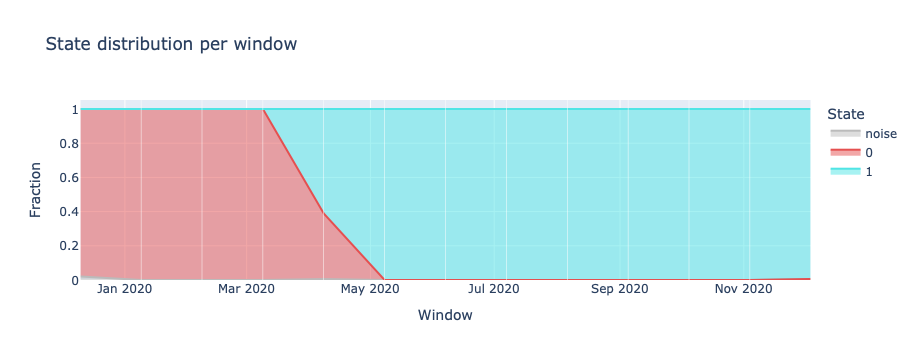

In [26]:
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

In [27]:
divergences = kairo.compute_divergences(freq_distributions)
divergences

,window,score
0,2019-12-10 00:00:00+00:00,NaN
1,2020-01-09 00:00:00+00:00,0.021053
2,2020-02-08 00:00:00+00:00,0.000000
3,2020-03-09 00:00:00+00:00,0.000000
4,2020-04-08 00:00:00+00:00,12.081980
5,2020-05-08 00:00:00+00:00,0.492476
6,2020-06-07 00:00:00+00:00,0.000000
7,2020-07-07 00:00:00+00:00,0.000000
8,2020-08-06 00:00:00+00:00,0.000000
9,2020-09-05 00:00:00+00:00,0.000000


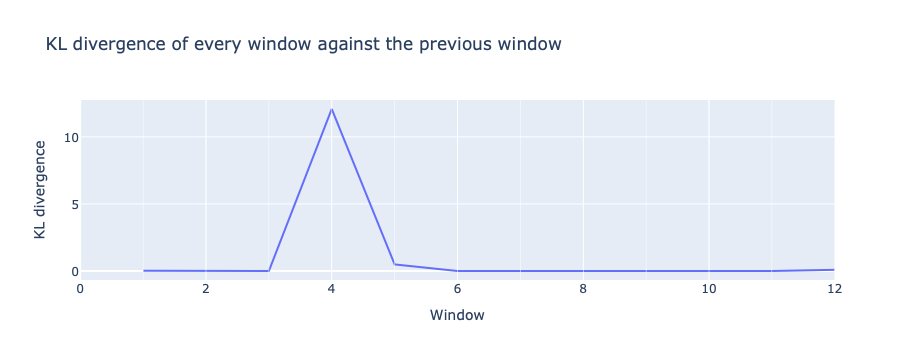

In [28]:
divergences_plot = kairo.plot_divergences(divergences)
divergences_plot.show()

In [29]:
window_distances = kairo.compute_window_distances(compressed_features, distance="euclidean", reference="previous")
window_distances

,window,score
0,2020-01-01 00:00:00+00:00,NaN
1,2020-01-01 04:00:00+00:00,1.648213
2,2020-01-01 08:00:00+00:00,0.776930
3,2020-01-01 12:00:00+00:00,0.862309
4,2020-01-01 16:00:00+00:00,0.818166
...,...,...
2187,2020-12-30 12:00:00+00:00,1.261935
2188,2020-12-30 16:00:00+00:00,1.537453
2189,2020-12-30 20:00:00+00:00,1.762301
2190,2020-12-31 00:00:00+00:00,1.981963


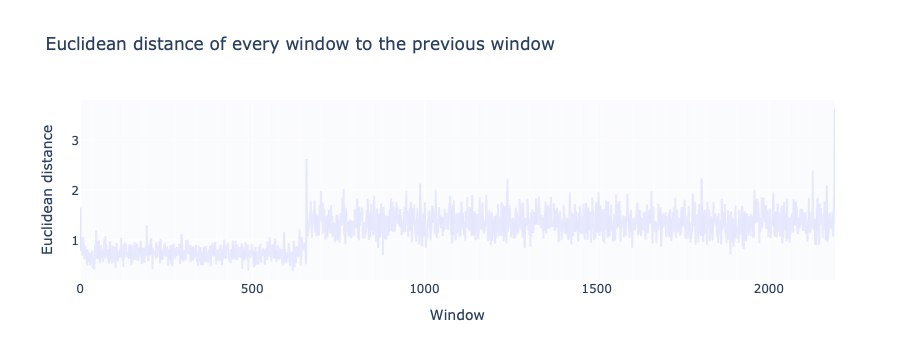

In [30]:
window_distances_plot = kairo.plot_window_distances(window_distances, distance="euclidean", reference="previous")
window_distances_plot.show()

In [31]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 1,767,057 events of 300,301 cases, 16 activities and 7 resources, from 2020-01-01 00:35:24.309885+00:00 to 2020-12-31 04:41:17.626539+00:00.\nThroughput time per case in days: min 0.00, mean 0.15, median 0.14, max 2.70.\nEvents per case: min 1, mean 5.9, median 6.0, max 85.\nEvents per activity: a (390,230), b (195,362), g (116,374), o (105,618), p (105,618), k (104,797), l (104,797), m (104,612), n (104,612), f (103,175), d (71,394), c (71,033), e (58,148), i (52,488), j (52,309), h (26,490)\nMost active resources: res_07 (588,709), res_05 (332,831), res_02 (274,796), res_04 (227,690), res_06 (138,464), res_03 (132,881), res_01 (71,686)'

In [32]:
abs_features = kairo.abstract_features(features)
abs_features

"Resource feature matrix: 2,192 rows, one per calendar window of 0 days 04:00:00, with 182 feature columns.\nThe windows start from 2020-01-01 00:00:00+00:00 to 2020-12-31 04:00:00+00:00.\nFeature groups:\n- res_events (events every resource executed in the window): 7 columns, mean value 115.163, non-zero in 100.0% of the cells, highest column means res_events:res_07 = 268.572, res_events:res_05 = 151.839, res_events:res_02 = 125.363\n- res_cases (distinct cases every resource touched in the window): 7 columns, mean value 95.337, non-zero in 100.0% of the cells, highest column means res_cases:res_07 = 198.882, res_cases:res_05 = 127.071, res_cases:res_02 = 103.401\n- res_durations (mean event duration in minutes of every resource in the window): 7 columns, mean value 31.129, non-zero in 100.0% of the cells, highest column means res_durations:res_07 = 36.013, res_durations:res_03 = 34.115, res_durations:res_04 = 32.963\n- res_waits (mean minutes since the previous event of the case, ove

In [33]:
abs_pca = kairo.abstract_pca(pca, cut_component=10)
abs_pca

'PCA fitted 50 components on 182 feature columns. The cut keeps the first 10, which explain 61.3% of the variance.\nExplained variance per component: pc_1 54.6%, pc_2 1.0%, pc_3 0.8%, pc_4 0.8%, pc_5 0.7%, pc_6 0.7%, pc_7 0.7%, pc_8 0.7%, pc_9 0.7%, pc_10 0.7%, pc_11 0.6%, pc_12 0.6%, pc_13 0.6%, pc_14 0.6%, pc_15 0.6%, pc_16 0.6%, pc_17 0.6%, pc_18 0.6%, pc_19 0.6%, pc_20 0.6%, pc_21 0.5%, pc_22 0.5%, pc_23 0.5%, pc_24 0.5%, pc_25 0.5%, pc_26 0.5%, pc_27 0.5%, pc_28 0.5%, pc_29 0.5%, pc_30 0.5%, pc_31 0.5%, pc_32 0.5%, pc_33 0.5%, pc_34 0.5%, pc_35 0.5%, pc_36 0.5%, pc_37 0.4%, pc_38 0.4%, pc_39 0.4%, pc_40 0.4%, pc_41 0.4%, pc_42 0.4%, pc_43 0.4%, pc_44 0.4%, pc_45 0.4%, pc_46 0.4%, pc_47 0.4%, pc_48 0.4%, pc_49 0.4%, pc_50 0.4%\nFeatures with the strongest loadings on every kept component:\n- pc_1: act_res_shares:l by res_02 (+0.22), act_res_shares:m by res_04 (+0.22), act_res_shares:k by res_05 (+0.22), act_res_shares:h by res_01 (+0.21)\n- pc_2: res_cases:res_01 (+0.40), res_event

In [34]:
abs_states = kairo.abstract_states(state_freqs, state_distances, color_mapping, clustering_scores=clustering_scores)
abs_states

'3 states occur among the 2,192 windows. Windows per state:\n- 1: 1,533 windows (69.9%)\n- 0: 656 windows (29.9%)\n- noise: 3 windows (0.1%)\nNearest and farthest other state for every state, by the distance between them:\n- 0: nearest 1 (3.95), farthest 1 (3.95)\n- 1: nearest 0 (3.95), farthest 0 (3.95)\nColors of the states in the plots:\n- 0: #e55050 (red)\n- 1: #50e5e5 (cyan)\n- noise: #bbbbbb (grey)\nClustering scores of the states:\n- DBCV: 0.718\n- Silhouette: 0.712\n- Calinski-Harabasz: 9,449.256'

In [35]:
abs_log_trajectory = kairo.abstract_log_trajectory(log_trajectory)
abs_log_trajectory

'Trajectory of the log through the states from 2020-01-01 00:00:00+00:00 to 2020-12-31 08:00:00+00:00: 2,192 calendar windows in 5 visits, a visit being a run of consecutive windows in the same state.\nWindows per state, and when the state first and last occurs:\n- 1: 1,533 windows (69.9%), from 2020-04-19 16:00:00+00:00 to 2020-12-31 04:00:00+00:00\n- 0: 656 windows (29.9%), from 2020-01-01 04:00:00+00:00 to 2020-04-19 12:00:00+00:00\n- noise: 3 windows (0.1%), from 2020-01-01 00:00:00+00:00 to 2020-12-31 08:00:00+00:00\nThe most common moves from one state to the next:\n- noise -> 0: 1 times\n- 0 -> noise: 1 times\n- noise -> 1: 1 times\n- 1 -> noise: 1 times\nThe visits in order:\n- noise from 2020-01-01 00:00:00+00:00 to 2020-01-01 04:00:00+00:00 (1 windows)\n- 0 from 2020-01-01 04:00:00+00:00 to 2020-04-19 12:00:00+00:00 (656 windows)\n- noise from 2020-04-19 12:00:00+00:00 to 2020-04-19 16:00:00+00:00 (1 windows)\n- 1 from 2020-04-19 16:00:00+00:00 to 2020-12-31 04:00:00+00:00 (1

In [36]:
abs_distributions = kairo.abstract_distributions(freq_distributions)
abs_distributions

'State distribution over 13 calendar windows from 2019-12-10 00:00:00+00:00 to 2020-12-04 00:00:00+00:00: the share of every state in each window.\nShare of every state over the windows, mean, lowest and highest:\n- noise: mean 0.2%, lowest 0.0% in the window starting 2020-01-09 00:00:00+00:00, highest 2.1% in the window starting 2019-12-10 00:00:00+00:00\n- 0: mean 33.6%, lowest 0.0% in the window starting 2020-05-08 00:00:00+00:00, highest 100.0% in the window starting 2020-01-09 00:00:00+00:00\n- 1: mean 66.2%, lowest 0.0% in the window starting 2019-12-10 00:00:00+00:00, highest 100.0% in the window starting 2020-05-08 00:00:00+00:00\nThe largest changes from one window to the next, with the states that changed most:\n- window starting 2020-04-08 00:00:00+00:00: 61.7% of the mix moved, 0 -61.7%, 1 +61.1%, noise +0.6%\n- window starting 2020-05-08 00:00:00+00:00: 38.9% of the mix moved, 1 +38.9%, 0 -38.3%, noise -0.6%\n- window starting 2020-01-09 00:00:00+00:00: 2.1% of the mix mov

In [37]:
abs_divergences = kairo.abstract_divergences(divergences, divergence="kl", reference="previous")
abs_divergences

'Drift signal: the KL divergence between the state distribution of every calendar window and the previous window, over 13 windows from 2019-12-10 00:00:00+00:00 to 2020-12-04 00:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 0.000, mean 1.057, highest 12.082.\nThe windows with the highest scores:\n- window 4, starting 2020-04-08 00:00:00+00:00: 12.082\n- window 5, starting 2020-05-08 00:00:00+00:00: 0.492\n- window 12, starting 2020-12-04 00:00:00+00:00: 0.089\n- window 1, starting 2020-01-09 00:00:00+00:00: 0.021\n- window 2, starting 2020-02-08 00:00:00+00:00: 0.000'

In [38]:
abs_window_distances = kairo.abstract_window_distances(window_distances, distance="euclidean", reference="previous")
abs_window_distances

'Drift signal: the Euclidean distance between the vector of every calendar window and the previous window, over 2192 windows from 2020-01-01 00:00:00+00:00 to 2020-12-31 04:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 1.215, mean 1.172, highest 3.622.\nThe windows with the highest scores:\n- window 2191, starting 2020-12-31 04:00:00+00:00: 3.622\n- window 657, starting 2020-04-19 12:00:00+00:00: 2.621\n- window 2127, starting 2020-12-20 12:00:00+00:00: 2.391\n- window 1805, starting 2020-10-27 20:00:00+00:00: 2.230\n- window 1241, starting 2020-07-25 20:00:00+00:00: 2.229'

In [45]:
llm = kairo.LLMConnector(
    provider="custom",
    #api_key=os.environ["ANTHROPIC_API_KEY"],
    model="nvidia/nemotron-3-nano-omni",
    #base_url="http://137.226.117.70:8000/v1"
    base_url = "http://127.0.0.1:1234/v1"
)

In [46]:
chat_history = []
total_out_tokens = 0

In [47]:
# For initial request
messages = kairo.create_messages(provider="custom",
                                system_prompt=kairo.DEFAULT_SYSTEM_PROMPT,
                                prompts=[abs_log_stats, abs_features, abs_pca, abs_states, abs_log_trajectory,
                                         abs_distributions, abs_divergences, abs_window_distances,
                                         "Do you see drift signal, if yes, which perspective is more likely? How successful/meaningful is the clustering? Very briefly explain."],
                                plots=[activity_plot, pca_plot_cut, distances_plot, freqs_plot,
                                       log_trajectory_plot, distributions_plot, divergences_plot, window_distances_plot])
chat_history += messages

num_tokens = kairo.count_input_tokens(provider="custom", messages=chat_history)
num_tokens

8203

In [51]:
# For follow up request
messages = kairo.create_messages(provider="custom",
                                system_prompt=None,
                                prompts=["What config could be testes to get more insights, brief answer"],
                                plots=[])
chat_history += messages

num_tokens = kairo.count_input_tokens(provider="custom", messages=chat_history)
num_tokens

8420

In [52]:
response = llm.call(messages=chat_history, max_tokens=1000)

answer = kairo.get_response_text(response)

chat_history.append({"role": "assistant", 
                     "content": answer})

print(answer)

Try a larger feature window (e.g., 7 D) with KL‑divergence against a “recent” baseline instead of the immediate previous window.


In [53]:
out_tokens = kairo.count_output_tokens("custom", response)
total_out_tokens += out_tokens
total_out_tokens

1115

In [50]:
print(kairo.get_chat_history(chat_history))

── system ──
(10,236 characters)

── user ──
Event log: 1,767,057 events of 300,301 cases, 16 activities and 7 resources, from 2020-01-01 00:35:24.309885+00:00 to 2020-12-31 04:41:17.626539+00:00.
Throughput time per case in days: min 0.00, mean 0.15, median 0.14, max 2.70.
Events per case: min 1, mean 5.9, median 6.0, max 85.
Events per activity: a (390,230), b (195,362), g (116,374), o (105,618), p (105,618), k (104,797), l (104,797), m (104,612), n (104,612), f (103,175), d (71,394), c (71,033), e (58,148), i (52,488), j (52,309), h (26,490)
Most active resources: res_07 (588,709), res_05 (332,831), res_02 (274,796), res_04 (227,690), res_06 (138,464), res_03 (132,881), res_01 (71,686)

Resource feature matrix: 2,192 rows, one per calendar window of 0 days 04:00:00, with 182 feature columns.
The windows start from 2020-01-01 00:00:00+00:00 to 2020-12-31 04:00:00+00:00.
Feature groups:
- res_events (events every resource executed in the window): 7 columns, mean value 115.163, non-zer